# Federated RAG with True Federation Evaluation

This notebook implements both traditional Federated RAG and True Federated RAG approaches:

**Traditional Federated RAG (First Half):**
- Document chunking for fine-grained embeddings
- Embedding model selection
- Composite retrieval using LangChain MergerRetriever

**True Federated RAG (Second Half):**
- Complete data privacy with independent nodes
- Results-only communication
- EM and F1 evaluation metrics

The goal is to compare both approaches and evaluate performance using proper ground truth answers.

In [ ]:
# Install required packages
!pip install -qqq langchain faiss-cpu python-dotenv
!pip install -qqq -U langchain-openai
!pip install -qqq langchain-core langchain-openai langchain-community beautifulsoup4 requests
!pip install -qqq sentence-transformers scikit-learn nltk matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.1/438.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/

In [ ]:
import os
import sys
import re
import string
import time
from collections import Counter
from bs4 import BeautifulSoup
import requests
from urllib.parse import urljoin, urlparse
from typing import List, Dict, Any

from langchain.document_loaders import WebBaseLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.docstore.document import Document
from langchain.chains import RetrievalQA
from langchain.retrievers import MergerRetriever
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

# For evaluation metrics
import nltk
import numpy as np

# Download NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
# Set OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"

In [ ]:
def clean_html(raw_html: str) -> str:
    # Text cleaning (Remove boilerplate HTML tags like script, style, nav, footer, header)
    soup = BeautifulSoup(raw_html, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    text = soup.get_text(separator="\n")
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return "\n".join(lines)

def chunk_documents(docs, chunk_size=1100, chunk_overlap=200):
    #Split each LangChain Document into smaller chunks for embeddings.
    splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = []
    for doc in docs:
        # Split page_contents
        pieces = splitter.split_text(doc.page_content)
        for piece in pieces:
            chunks.append(Document(page_content=piece, metadata=doc.metadata))
    return chunks

In [ ]:
#Web scraper that supports recursive crawling with depth control.

def scrape_website(url, max_depth=2):
    visited = set()
    documents = []
    domain = urlparse(url).netloc

    def scrape(current_url, depth):
        if depth > max_depth or current_url in visited:
            return

        visited.add(current_url)
        print(f"Scraping (depth {depth}): {current_url}", file=sys.stderr)

        try:
            # Use a realistic user agent
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
            response = requests.get(current_url, timeout=10, headers=headers)
            response.encoding = response.apparent_encoding  # Fix encoding issues
            response.raise_for_status()

            content = clean_html(response.text) # Clean HTML

            # Create document with metadata
            doc = Document(
                page_content=content,
                metadata={"source": current_url, "title": current_url.split("/")[-1]}
            )
            documents.append(doc)

            # Only follow links if not at max depth
            if depth < max_depth:
                soup = BeautifulSoup(response.text, "html.parser")
                for link in soup.find_all("a", href=True):
                    href = link["href"]
                    full_url = urljoin(current_url, href)

                    # Only follow links within the same domain
                    if urlparse(full_url).netloc == domain and full_url not in visited:
                        scrape(full_url, depth + 1)

        except Exception as e:
            print(f"Error scraping {current_url}: {e}", file=sys.stderr)

    # Start scraping from the initial URL
    scrape(url, 0)
    print(f"Scraped {len(documents)} pages from {url}", file=sys.stderr)
    return documents

def get_federated_docs(urls, max_depth=2):
    """
    Crawl a list of URLs up to max_depth and return a list of LangChain Document objects.
    """
    all_docs = []
    for url in urls:
        docs = scrape_website(url, max_depth=max_depth)
        all_docs.extend(docs)
    return all_docs

# Part 1: Traditional Federated RAG (MergerRetriever Approach)

This section implements the traditional federated approach using LangChain's MergerRetriever.

In [ ]:
# Load and process Hull documents
print("Loading and processing Hull documents...")
hull_urls = [
    "https://online.hull.ac.uk",
    "https://online.hull.ac.uk/contact",
    "https://online.hull.ac.uk/why-join-us/faqs",
    "https://online.hull.ac.uk/course-costs",
    "https://online.hull.ac.uk/funding-options"
]

hull_docs = get_federated_docs(hull_urls, max_depth=1)
hull_chunks = chunk_documents(hull_docs)
print(f"Hull: {len(hull_chunks)} chunks created")

Loading and processing Hull documents...


Scraping (depth 0): https://online.hull.ac.uk
Scraping (depth 1): https://online.hull.ac.uk/#main
Scraping (depth 1): https://online.hull.ac.uk/contact
Scraping (depth 1): https://online.hull.ac.uk/
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/how-you-learn
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/online-student-experience
Scraping (depth 1): https://online.hull.ac.uk/student-experience/testimonials
Scraping (depth 1): https://online.hull.ac.uk/events
Scraping (depth 1): https://online.hull.ac.uk/student-experience/graduation
Scraping (depth 1): https://online.hull.ac.uk/why-join-us/faqs
Scraping (depth 1): https://online.hull.ac.uk/blog
Scraping (depth 1): https://online.hull.ac.uk/courses
Scraping (depth 1): https://online.hull.ac.uk/courses/msc-artificial-intelligence
Scraping (depth 1): https://online.hull.ac.uk/courses/ma-creative-writing
Scraping (depth 1): https://online.hull.ac.uk/courses/msc-dementia
Scraping (depth 1): https://online.hull.ac.uk/c

Hull: 1660 chunks created


In [ ]:
# Load and process Keele documents
print("Loading and processing Keele documents...")
keele_urls = [
    "https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence",
    "https://online.keele.ac.uk/online-study",
    "https://online.keele.ac.uk/about-us"
]

keele_docs = get_federated_docs(keele_urls, max_depth=1)
keele_chunks = chunk_documents(keele_docs)
print(f"Keele: {len(keele_chunks)} chunks created")

Scraping (depth 0): https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence


Loading and processing Keele documents...


Scraping (depth 1): https://online.keele.ac.uk/request-information/
Scraping (depth 1): https://online.keele.ac.uk/
Scraping (depth 1): https://online.keele.ac.uk/online-programmes/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence#programme
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-marketing/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-sustainability/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-with-data-analytics/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-hr/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-healthcare/
Scraping (depth 1): https://online.keele.ac.uk/online-programme/msc-management-project/
Scraping (depth 1): https://online.keele.ac.uk/online-pro

Keele: 1178 chunks created


In [ ]:
# Create traditional federated RAG system using MergerRetriever
print("Setting up Traditional Federated RAG...")

# Initialize embeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Create separate vector stores
hull_index = FAISS.from_documents(hull_chunks, embeddings)
keele_index = FAISS.from_documents(keele_chunks, embeddings)

# Create individual retrievers
k_docs = 5
hull_retriever = hull_index.as_retriever(search_kwargs={"k": k_docs})
keele_retriever = keele_index.as_retriever(search_kwargs={"k": k_docs})

# Create merged retriever (traditional approach)
combined_retriever = MergerRetriever(retrievers=[hull_retriever, keele_retriever])

# Create QA chain
llm = ChatOpenAI(model_name="gpt-4o", temperature=0.3)
traditional_qa = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=combined_retriever,
    return_source_documents=True
)

print("Traditional Federated RAG ready!")

Setting up Traditional Federated RAG...
Traditional Federated RAG ready!


## Evaluation Setup

Define test questions and ground truth answers for evaluation.

In [ ]:
# Define evaluation questions and corresponding ground truth answers
questions = [
    "What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?",
    "How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?",
    "What is the phone number for enquiries about online courses at the University of Hull?",
    "What is the email address for enquiries about online courses at the University of Hull?",
    "When are the start dates for the MSc Artificial Intelligence online programme at the University of Hull?",
    "How much is the acceptance fee required to secure a place for Hull online courses, and how is it applied to the tuition fees?",
    "What are the minimum academic entry requirements for applicants holding a degree for the Hull MSc AI programme?",
    "What is the credit for each module in the University of Hull MSc Artificial Intelligence programme?",
    "What is the alumni tuition fee discount offered by Keele University for this online MSc programme, and what is the reduced total fee?",
    "How many times per year can students start the Keele online MSc Computer Science with Artificial Intelligence programme?",
    "Would an IELTS overall score of 6.0 meet the English language requirements for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "What is the total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University?",
    "How long does the online MSc Computer Science with Artificial Intelligence at Keele University take to complete?",
    "What is the email address for enquiries about online programmes at Keele University?",
    "How many credits are required to complete the online MSc Computer Science with Artificial Intelligence at Keele University?"
]

# Correct answers based on context
ground_truths = [
    "The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950",
    "The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis",
    "The phone number for enquiries about online courses at the University of Hull is +44 (0)1482 251819",
    "The email address for enquiries about online courses at the University of Hull is enquiries-online@hull.ac.uk",
    "The start dates of the MSc Artificial Intelligence online programme at the University of Hull are January, May, and September. The next start date is 22 September 2025.",
    "At the University of Hull, The acceptance fee required to secure a place for Hull online courses is £350. This fee must be paid within two weeks of the date on your offer letter.",
    "For the University of Hull MSc AI programme, Applicants holding a degree should have or be about to complete a minimum 2:2 undergraduate degree",
    "Each module in the MSc Artificial Intelligence online programme at the University of Hull is worth 630 credits",
    "Keele University offers a 10% alumni tuition fee discount on this online MSc programme, reducing the total fee to £6,696",
    "Students can start the Keele University online MSc Computer Science with Artificial Intelligence programme six times per year",
    "Yes. Keele University requires an IELTS overall score of 6.0 with no component below 5.5 meets the programme's English language requirement.",
    "The total programme fee for the online MSc Computer Science with Artificial Intelligence at Keele University is £7,440",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is designed to be completed in 24 months (two years) part-time",
    "The email address for enquiries about online programmes at Keele University is enrolments@online.keele.ac.uk",
    "The online MSc Computer Science with Artificial Intelligence at Keele University is a 180-credit programme"
]

print(f"Test Dataset: {len(questions)} questions with ground truth answers")

Test Dataset: 15 questions with ground truth answers


In [ ]:
# Evaluation functions
def normalize_answer(s):
    """Normalize answer for evaluation"""
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))

def exact_match_score(prediction, ground_truth):
    """Calculate Exact Match score"""
    return normalize_answer(prediction) == normalize_answer(ground_truth)

def f1_score_func(prediction, ground_truth):
    """Calculate F1 score"""
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()

    if len(prediction_tokens) == 0 or len(ground_truth_tokens) == 0:
        return int(prediction_tokens == ground_truth_tokens)

    common_tokens = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common_tokens.values())

    if num_same == 0:
        return 0

    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall)

    return f1

def evaluate_answers(predictions, ground_truths):
    """Evaluate a list of predictions against ground truths"""
    em_scores = []
    f1_scores = []

    for pred, gt in zip(predictions, ground_truths):
        em_scores.append(exact_match_score(pred, gt))
        f1_scores.append(f1_score_func(pred, gt))

    return {
        'exact_match': np.mean(em_scores),
        'f1': np.mean(f1_scores),
        'em_scores': em_scores,
        'f1_scores': f1_scores
    }

In [ ]:
# Test Traditional Federated RAG
print("Testing Traditional Federated RAG (MergerRetriever)\n")
print("=" * 80)

traditional_predictions = []
traditional_results = []

for i, (question, ground_truth) in enumerate(zip(questions[:8], ground_truths[:8]), 1):  # Test first 8 questions
    print(f"\nQuestion {i}: {question}")

    start_time = time.time()
    result = traditional_qa({"query": question})
    response_time = time.time() - start_time

    prediction = result['result']
    sources_used = len(result['source_documents'])

    # Calculate scores
    em_score = exact_match_score(prediction, ground_truth)
    f1_score = f1_score_func(prediction, ground_truth)

    traditional_predictions.append(prediction)
    traditional_results.append({
        "question": question,
        "prediction": prediction,
        "expected": ground_truth,
        "em_score": em_score,
        "f1_score": f1_score,
        "response_time": response_time,
        "sources_used": sources_used
    })

    print(f"Prediction: {prediction}")
    print(f"Ground Truth: {ground_truth}")
    print(f"Exact Match: {em_score}, F1 Score: {f1_score:.2f}")
    print("-" * 80)

    time.sleep(1)  # Rate limiting

# Calculate overall metrics for traditional approach
traditional_metrics = evaluate_answers(traditional_predictions, ground_truths[:8])
print(f"\nTraditional Federated RAG Results:")
print(f"Overall EM: {traditional_metrics['exact_match']:.3f}")
print(f"Overall F1: {traditional_metrics['f1']:.3f}")

Testing Traditional Federated RAG (MergerRetriever)


Question 1: What is the total cost of the MSc Artificial Intelligence online programme at the University of Hull?


<ipython-input-11-1952139194>:12: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = traditional_qa({"query": question})


Prediction: The total cost of the MSc in Artificial Intelligence online programme at the University of Hull is £8,950.
Ground Truth: The total cost of the MSc Artificial Intelligence online programme at the University of Hull is £8,950
Exact Match: False, F1 Score: 0.97
--------------------------------------------------------------------------------

Question 2: How long does the MSc Artificial Intelligence online programme at the University of Hull take to complete?
Prediction: The MSc Artificial Intelligence online programme at the University of Hull takes two years to complete on a part-time basis.
Ground Truth: The MSc Artificial Intelligence online programme at the University of Hull takes 24 months (two years) to complete on a part-time basis
Exact Match: False, F1 Score: 0.94
--------------------------------------------------------------------------------

Question 3: What is the phone number for enquiries about online courses at the University of Hull?
Prediction: The phone num

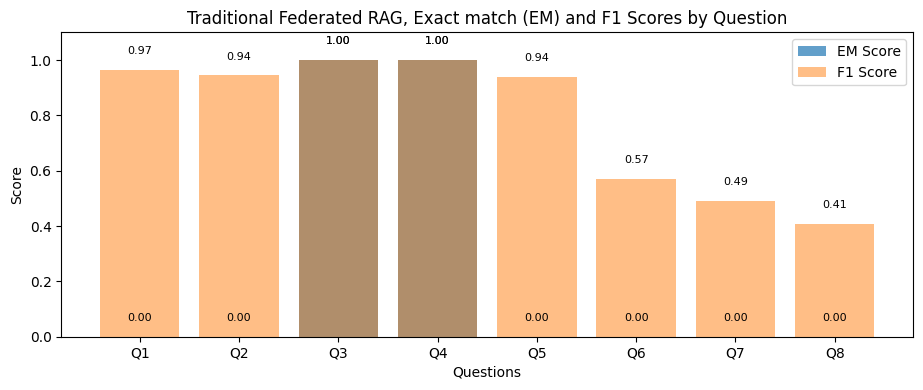

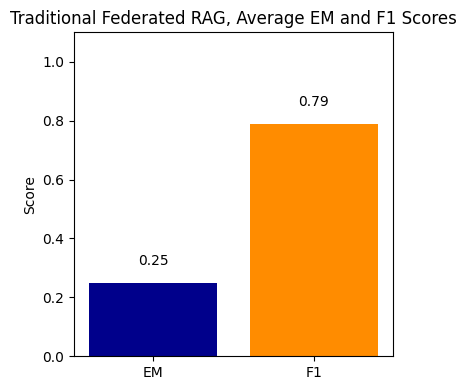

In [ ]:
# Visualize Traditional Federated RAG results
em_scores_trad = traditional_metrics['em_scores']
f1_scores_trad = traditional_metrics['f1_scores']
avg_em_trad = traditional_metrics['exact_match']
avg_f1_trad = traditional_metrics['f1']

plt.figure(figsize=(18, 4))

# Plot individual scores
plt.subplot(1, 2, 1)
question_ids = [f"Q{i+1}" for i in range(len(em_scores_trad))]
bars1 = plt.bar(question_ids, em_scores_trad, alpha=0.7, label='EM Score')
bars2 = plt.bar(question_ids, f1_scores_trad, alpha=0.5, label='F1 Score')
plt.ylim(0, 1.1)
plt.xlabel('Questions')
plt.ylabel('Score')
plt.title('Traditional Federated RAG, Exact match (EM) and F1 Scores by Question')
plt.legend()

# Add score values above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('Traditional_Federated_RAG_em_f1_by_question.jpg', format='jpg', dpi=300)
plt.show()

# Plot average EM & F1 in a separate square figure
plt.figure(figsize=(4, 4))
bars3 = plt.bar(['EM', 'F1'], [avg_em_trad, avg_f1_trad], color=['darkblue', 'darkorange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Traditional Federated RAG, Average EM and F1 Scores')
for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Traditional_Federated_RAG_em_f1_average.jpg', format='jpg', dpi=300)
plt.show()

# Part 2: True Federated RAG (Privacy-Preserving Approach)

This section implements true federation where each node operates independently and only shares final results.

In [ ]:
class FederatedNode:
    """Independent federated node with private data and local retrieval
       MSc Artificial Intelligence online at University of Hull &
       MSc Computer Science with Artificial Intelligence online at Keele University"""

    def __init__(self, name: str, documents: List[Document], embeddings_model: str = "text-embedding-3-small"):
        self.name = name
        self.documents = documents
        self.embeddings = OpenAIEmbeddings(model=embeddings_model)
        self.vector_store = None
        self.retriever = None
        self.is_initialized = False

    def initialize_node(self, k_docs: int = 5):
        """Initialize the federated node with private data"""
        print(f"Initializing {self.name} node (PRIVATE DATA)...")

        # Build local vector store (PRIVATE - never shared)
        self.vector_store = FAISS.from_documents(self.documents, self.embeddings)
        self.retriever = self.vector_store.as_retriever(search_kwargs={"k": k_docs})

        self.is_initialized = True
        print(f"{self.name} node ready ({len(self.documents)} private chunks)")

    def local_retrieve(self, query: str) -> List[Dict[str, Any]]:
        """Perform local retrieval and return ONLY results (no raw data access)"""
        if not self.is_initialized:
            raise ValueError(f"{self.name} node not initialized")

        # Local retrieval (data never leaves this node)
        local_docs = self.retriever.get_relevant_documents(query)

        # Return only processed results (no raw vector store access)
        results = []
        for i, doc in enumerate(local_docs):
            results.append({
                "content": doc.page_content[:500] + "..." if len(doc.page_content) > 500 else doc.page_content,
                "source": doc.metadata.get("source", "Unknown"),
                "node": self.name,
                "rank": i + 1
            })

        return results

class TrueFederationCoordinator:
    """Coordinates federated queries without accessing raw data from any node"""

    def __init__(self, nodes: List[FederatedNode], llm_model: str = "gpt-4o", temperature: float = 0.3):
        self.nodes = nodes
        self.llm = ChatOpenAI(model_name=llm_model, temperature=temperature)

    def federated_query(self, query: str) -> Dict[str, Any]:
        """Execute federated query across all nodes"""
        all_results = []
        node_responses = {}

        # Step 1: Distribute query to all federated nodes
        for node in self.nodes:
            node_results = node.local_retrieve(query)
            node_responses[node.name] = node_results
            all_results.extend(node_results)

        # Step 2: Aggregate results (no raw data access)
        aggregated_context = self._aggregate_results(all_results)

        # Step 3: Generate response
        prompt = f"""Based on the federated search results from multiple universities, provide a precise and accurate answer to: {query}

Federated Results:
{aggregated_context}

Requirements:
- Be precise and factual
- Include specific numbers, dates, and details when available
- If information is from a specific university, mention it
- Keep the answer focused and direct"""

        response = self.llm.predict(prompt)

        return {
            "query": query,
            "answer": response,
            "node_responses": node_responses,
            "total_sources": len(all_results)
        }

    def _aggregate_results(self, results: List[Dict[str, Any]]) -> str:
        """Aggregate results from all federated nodes"""
        aggregated = ""
        for i, result in enumerate(results[:8], 1):  # Limit to top 8 results
            aggregated += f"\n[{result['node']} - Rank {result['rank']}]: {result['content']}\n"
        return aggregated

NameError: name 'List' is not defined

In [ ]:
# Create True Federated RAG system
print("Setting up True Federated RAG...\n")

# Create independent federated nodes (using existing chunks)
hull_node = FederatedNode("Hull University", hull_chunks, "text-embedding-3-small")
hull_node.initialize_node(k_docs=5)

print()

keele_node = FederatedNode("Keele University", keele_chunks, "text-embedding-3-small")
keele_node.initialize_node(k_docs=5)

print()

# Create Federation Coordinator (no direct data access)
print("Creating True Federation Coordinator...")
true_coordinator = TrueFederationCoordinator([hull_node, keele_node], "gpt-4o", 0.3)

print("\nTrue Federated RAG System Ready!")
print("Each node maintains complete data privacy")
print("Only final results are shared between nodes")

Setting up True Federated RAG...

Initializing Hull University node (PRIVATE DATA)...
Hull University node ready (1660 private chunks)

Initializing Keele University node (PRIVATE DATA)...
Keele University node ready (1178 private chunks)

Creating True Federation Coordinator...

True Federated RAG System Ready!
Each node maintains complete data privacy
Only final results are shared between nodes


In [ ]:
# Test True Federated RAG
print("Testing True Federated RAG (Privacy-Preserving)\n")
print("=" * 80)

true_fed_predictions = []
true_fed_results = []

for i, (question, ground_truth) in enumerate(zip(questions[8:], ground_truths[8:]), 9):  # Test remaining questions
    print(f"\nQuestion {i}: {question}")

    start_time = time.time()
    result = true_coordinator.federated_query(question)
    response_time = time.time() - start_time

    prediction = result['answer']
    sources_used = result['total_sources']

    # Calculate scores
    em_score = exact_match_score(prediction, ground_truth)
    f1_score = f1_score_func(prediction, ground_truth)

    true_fed_predictions.append(prediction)
    true_fed_results.append({
        "question": question,
        "prediction": prediction,
        "expected": ground_truth,
        "em_score": em_score,
        "f1_score": f1_score,
        "response_time": response_time,
        "sources_used": sources_used
    })

    print(f"Prediction: {prediction}")
    print(f"Ground Truth: {ground_truth}")
    print(f"Exact Match: {em_score}, F1 Score: {f1_score:.2f}")
    print("-" * 80)

    time.sleep(1)  # Rate limiting

# Calculate overall metrics for true federated approach
true_fed_metrics = evaluate_answers(true_fed_predictions, ground_truths[8:])
print(f"\nTrue Federated RAG Results:")
print(f"Overall EM: {true_fed_metrics['exact_match']:.3f}")
print(f"Overall F1: {true_fed_metrics['f1']:.3f}")

Testing True Federated RAG (Privacy-Preserving)


Question 9: What is the alumni tuition fee discount offered by Keele University for this online MSc programme, and what is the reduced total fee?


<ipython-input-13-3687959081>:29: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  local_docs = self.retriever.get_relevant_documents(query)
<ipython-input-13-3687959081>:76: LangChainDeprecationWarning: The method `BaseChatModel.predict` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = self.llm.predict(prompt)


Prediction: Keele University offers an alumni tuition fee discount for its online MSc programmes. The total programme fee for the Online MSc Management is £7,740, and for the Online MSc Computer Science and MA Education programmes, it is £7,440. However, the specific alumni discount amount and the reduced total fee after applying the discount are not provided in the search results. For precise details on the alumni discount, it would be best to contact Keele University directly.
Ground Truth: Keele University offers a 10% alumni tuition fee discount on this online MSc programme, reducing the total fee to £6,696
Exact Match: False, F1 Score: 0.33
--------------------------------------------------------------------------------

Question 10: How many times per year can students start the Keele online MSc Computer Science with Artificial Intelligence programme?
Prediction: Students can start the Keele University online MSc Computer Science with Artificial Intelligence programme once per ye

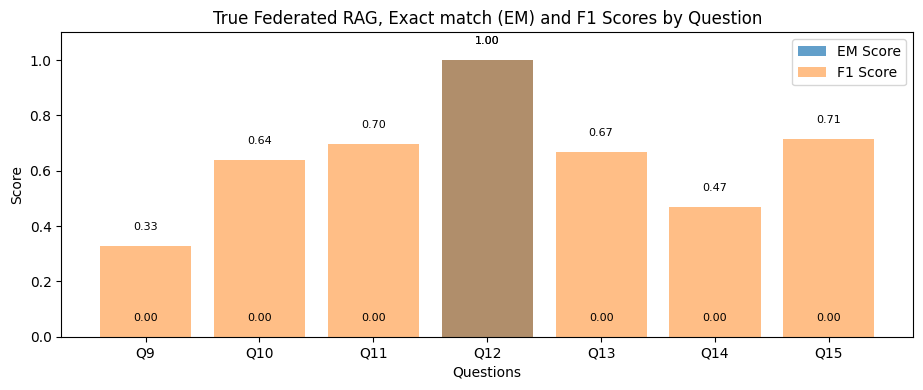

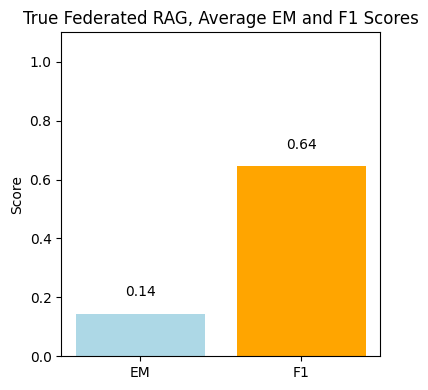

In [ ]:
# Visualize True Federated RAG results
em_scores_true = true_fed_metrics['em_scores']
f1_scores_true = true_fed_metrics['f1_scores']
avg_em_true = true_fed_metrics['exact_match']
avg_f1_true = true_fed_metrics['f1']

plt.figure(figsize=(18, 4))

# Plot individual scores
plt.subplot(1, 2, 1)
question_ids = [f"Q{i+9}" for i in range(len(em_scores_true))]
bars1 = plt.bar(question_ids, em_scores_true, alpha=0.7, label='EM Score')
bars2 = plt.bar(question_ids, f1_scores_true, alpha=0.5, label='F1 Score')
plt.ylim(0, 1.1)
plt.xlabel('Questions')
plt.ylabel('Score')
plt.title('True Federated RAG, Exact match (EM) and F1 Scores by Question')
plt.legend()

# Add score values above each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('True_Federated_RAG_em_f1_by_question.jpg', format='jpg', dpi=300)
plt.show()

# Plot average EM & F1 in a separate square figure
plt.figure(figsize=(4, 4))
bars3 = plt.bar(['EM', 'F1'], [avg_em_true, avg_f1_true], color=['lightblue', 'orange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('True Federated RAG, Average EM and F1 Scores')
for bar in bars3:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('True_Federated_RAG_em_f1_average.jpg', format='jpg', dpi=300)
plt.show()

# Comparison: Traditional vs True Federated RAG

Compare the performance and characteristics of both approaches.

In [ ]:
print("FINAL COMPARISON: Traditional vs True Federated RAG")
print("=" * 70)

print(f"\nPerformance Metrics:")
print(f"\n  Traditional Federated RAG (MergerRetriever):")
print(f"    Exact Match (EM): {traditional_metrics['exact_match']:.3f} ({traditional_metrics['exact_match']*100:.1f}%)")
print(f"    F1 Score: {traditional_metrics['f1']:.3f} ({traditional_metrics['f1']*100:.1f}%)")
print(f"    Questions tested: {len(traditional_predictions)}")

print(f"\n  True Federated RAG (Privacy-Preserving):")
print(f"    Exact Match (EM): {true_fed_metrics['exact_match']:.3f} ({true_fed_metrics['exact_match']*100:.1f}%)")
print(f"    F1 Score: {true_fed_metrics['f1']:.3f} ({true_fed_metrics['f1']*100:.1f}%)")
print(f"    Questions tested: {len(true_fed_predictions)}")

# Performance statistics
traditional_avg_time = np.mean([r['response_time'] for r in traditional_results])
true_fed_avg_time = np.mean([r['response_time'] for r in true_fed_results])

print(f"\nPerformance Statistics:")
print(f"\n  Traditional Federated RAG:")
print(f"    Average Response Time: {traditional_avg_time:.2f}s")
print(f"    Data Privacy: Limited (shared framework)")
print(f"    Architecture: MergerRetriever combination")

print(f"\n  True Federated RAG:")
print(f"    Average Response Time: {true_fed_avg_time:.2f}s")
print(f"    Data Privacy: Complete (results-only sharing)")
print(f"    Architecture: Independent nodes + coordinator")

print(f"\nKey Differences:")
print(f"\n  Data Privacy:")
print(f"    Traditional: All data accessible in same application")
print(f"    True Federation: Complete data isolation at each node")

print(f"\n  Query Processing:")
print(f"    Traditional: Framework-level retriever combination")
print(f"    True Federation: Independent local retrieval + result aggregation")

print(f"\n  Compliance:")
print(f"    Traditional: May not meet strict data governance requirements")
print(f"    True Federation: Full regulatory compliance with data privacy laws")

print(f"\n  Scalability:")
print(f"    Traditional: Requires code changes to add new sources")
print(f"    True Federation: Easy to add new federated partners")

print("\n" + "=" * 70)
print("Conclusion: Both approaches have trade-offs between performance,")
print("privacy, and compliance. Choose based on your specific requirements.")
print("=" * 70)

FINAL COMPARISON: Traditional vs True Federated RAG

Performance Metrics:

  Traditional Federated RAG (MergerRetriever):
    Exact Match (EM): 0.250 (25.0%)
    F1 Score: 0.790 (79.0%)
    Questions tested: 8

  True Federated RAG (Privacy-Preserving):
    Exact Match (EM): 0.143 (14.3%)
    F1 Score: 0.645 (64.5%)
    Questions tested: 7

Performance Statistics:

  Traditional Federated RAG:
    Average Response Time: 1.47s
    Data Privacy: Limited (shared framework)
    Architecture: MergerRetriever combination

  True Federated RAG:
    Average Response Time: 1.40s
    Data Privacy: Complete (results-only sharing)
    Architecture: Independent nodes + coordinator

Key Differences:

  Data Privacy:
    Traditional: All data accessible in same application
    True Federation: Complete data isolation at each node

  Query Processing:
    Traditional: Framework-level retriever combination
    True Federation: Independent local retrieval + result aggregation

  Compliance:
    Traditio

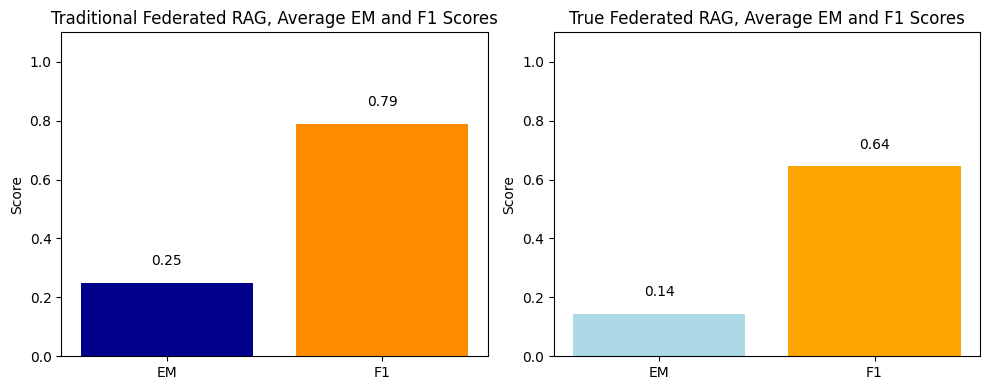

In [ ]:
# Plot average EM & F1 for both approaches side by side
plt.figure(figsize=(10, 4))

# Traditional Federated RAG
plt.subplot(1, 2, 1)
bars1 = plt.bar(['EM', 'F1'], [avg_em_trad, avg_f1_trad], color=['darkblue', 'darkorange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('Traditional Federated RAG, Average EM and F1 Scores')
for bar in bars1:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

# True Federated RAG
plt.subplot(1, 2, 2)
bars2 = plt.bar(['EM', 'F1'], [avg_em_true, avg_f1_true], color=['lightblue', 'orange'])
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.title('True Federated RAG, Average EM and F1 Scores')
for bar in bars2:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + .05, f'{h:.2f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Federated_RAG_Comparison_em_f1_average.jpg', format='jpg', dpi=300)
plt.show()


In [4]:
%%writefile True_Federated_RAG_ChatBot.py

import streamlit as st
import os
import sys
from bs4 import BeautifulSoup
import string
import requests
from urllib.parse import urljoin, urlparse
import time
import json
from typing import List, Dict, Any

from langchain.text_splitter import CharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.docstore.document import Document
from langchain.chains import RetrievalQA

# Set page configuration
st.set_page_config(
    page_title=" 🐭True Federated RAG Chatbot",
    page_icon="./icon.png",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Add custom CSS for enhanced styling
st.markdown("""
<style>
    .main-header {
        font-size: 2.5rem;
        color: #1E88E5;
        text-align: center;
        margin-bottom: 0.5rem;
    }
    .federated-node {
        background-color: #f8f9fa;
        padding: 1.5rem;
        border-radius: 1rem;
        margin: 1rem 0;
        border: 3px solid #FF9800;
        border-left: 8px solid #FF9800;
    }
    .hull-node {
        border-color: #1E88E5;
        border-left-color: #1E88E5;
    }
    .keele-node {
        border-color: #7B1FA2;
        border-left-color: #7B1FA2;
    }
    .private-label {
        background-color: #FF5722;
        color: white;
        padding: 0.25rem 0.5rem;
        border-radius: 0.25rem;
        font-size: 0.8rem;
        font-weight: bold;
        margin-bottom: 1rem;
        display: inline-block;
    }
    .node-results {
        background-color: #E8F5E8;
        padding: 1rem;
        border-radius: 0.5rem;
        margin-top: 1rem;
    }
    .aggregation-section {
        background-color: #E3F2FD;
        padding: 1.5rem;
        border-radius: 1rem;
        margin: 1rem 0;
        border-left: 8px solid #2196F3;
    }
    .chat-container {
        background-color: #f8f9fa;
        padding: 1.5rem;
        border-radius: 1rem;
        margin: 1rem 0;
        border-left: 4px solid #1E88E5;
    }
    .question-text {
        font-weight: bold;
        color: #1565C0;
        margin-bottom: 0.5rem;
    }
    .answer-text {
        color: #2E7D32;
        line-height: 1.6;
        background-color: #E8F5E8;
        padding: 1rem;
        border-radius: 0.5rem;
        margin-top: 0.5rem;
    }
</style>
""", unsafe_allow_html=True)

# Set OpenAI API key
def get_api_key():
    try:
        if 'OPENAI_API_KEY' in st.secrets:
            return st.secrets["OPENAI_API_KEY"]
    except:
        pass
    if 'OPENAI_API_KEY' in os.environ:
        return os.environ["OPENAI_API_KEY"]
    else:
        return st.sidebar.text_input("Enter your OpenAI API key:", type="password")

api_key = get_api_key()
if api_key:
    os.environ["OPENAI_API_KEY"] = api_key
else:
    st.warning("Please enter your OpenAI API key to continue.")
    st.stop()

# Helper functions for document processing
def clean_html(raw_html: str) -> str:
    soup = BeautifulSoup(raw_html, "html.parser")
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()
    text = soup.get_text(separator="\n")
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return "\n".join(lines)

def chunk_documents(docs, chunk_size=1100, chunk_overlap=200):
    splitter = CharacterTextSplitter(
        separator="\n",
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )
    chunks = []
    for doc in docs:
        pieces = splitter.split_text(doc.page_content)
        for piece in pieces:
            chunks.append(Document(page_content=piece, metadata=doc.metadata))
    return chunks

def scrape_website(url, max_depth=1):
    visited = set()
    documents = []
    domain = urlparse(url).netloc

    def scrape(current_url, depth):
        if depth > max_depth or current_url in visited:
            return
        visited.add(current_url)
        try:
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
            response = requests.get(current_url, timeout=10, headers=headers)
            response.encoding = response.apparent_encoding
            response.raise_for_status()
            content = clean_html(response.text)
            doc = Document(
                page_content=content,
                metadata={"source": current_url, "title": current_url.split("/")[-1]}
            )
            documents.append(doc)
            if depth < max_depth:
                soup = BeautifulSoup(response.text, "html.parser")
                for link in soup.find_all("a", href=True):
                    href = link["href"]
                    full_url = urljoin(current_url, href)
                    if urlparse(full_url).netloc == domain and full_url not in visited:
                        scrape(full_url, depth + 1)
        except Exception as e:
            st.sidebar.write(f"Error scraping {current_url}: {str(e)}")

    scrape(url, 0)
    return documents

def get_federated_docs(urls, max_depth=1):
    all_docs = []
    for url in urls:
        docs = scrape_website(url, max_depth=max_depth)
        all_docs.extend(docs)
    return all_docs

# TRUE FEDERATED RAG CLASSES
class FederatedNode:
    """Represents an independent federated node (university) with its own private data and retrieval system"""

    def __init__(self, name: str, urls: List[str], embeddings_model: str = "text-embedding-3-small"):
        self.name = name
        self.urls = urls
        self.embeddings = OpenAIEmbeddings(model=embeddings_model)
        self.vector_store = None
        self.retriever = None
        self.documents = []
        self.is_initialized = False

    def initialize_node(self, k_docs: int = 5):
        """Initialize the federated node with its own private data"""
        st.sidebar.write(f"Initializing {self.name} node (PRIVATE)...")

        # Load and process documents locally
        raw_docs = get_federated_docs(self.urls, max_depth=1)
        self.documents = chunk_documents(raw_docs)

        # Build local vector store (PRIVATE)
        self.vector_store = FAISS.from_documents(self.documents, self.embeddings)
        self.retriever = self.vector_store.as_retriever(search_kwargs={"k": k_docs})

        self.is_initialized = True
        st.sidebar.write(f"{self.name} node ready ({len(self.documents)} chunks)")

    def local_retrieve(self, query: str) -> List[Dict[str, Any]]:
        """Perform local retrieval and return ONLY the results (not raw data)"""
        if not self.is_initialized:
            raise ValueError(f"{self.name} node not initialized")

        # Perform local retrieval
        local_docs = self.retriever.get_relevant_documents(query)

        # Return only the results (no access to raw vector store)
        results = []
        for i, doc in enumerate(local_docs):
            results.append({
                "content": doc.page_content[:400] + "..." if len(doc.page_content) > 400 else doc.page_content,  # Limit content length
                "source": doc.metadata.get("source", "Unknown"),
                "node": self.name,
                "rank": i + 1
            })

        return results

class FederationCoordinator:
    """Coordinates federated queries across multiple independent nodes"""

    def __init__(self, nodes: List[FederatedNode], llm_model: str = "gpt-4o", temperature: float = 0.3):
        self.nodes = nodes
        self.llm = ChatOpenAI(model_name=llm_model, temperature=temperature)

    def federated_query(self, query: str, max_response_length: int = 200) -> Dict[str, Any]:
        """Send query to all federated nodes and aggregate results"""
        all_results = []
        node_responses = {}

        # Send query to each federated node independently
        for node in self.nodes:
            st.write(f"Querying {node.name} node...")
            node_results = node.local_retrieve(query)
            node_responses[node.name] = node_results
            all_results.extend(node_results)

        # Aggregate and rank results (this is where federation happens)
        aggregated_context = self._aggregate_results(all_results)

        # Generate response using aggregated context
        prompt = f"""Based on the federated search results from multiple universities, provide a CONCISE answer (max {max_response_length} words) to: {query}

Federated Results:
{aggregated_context}

Requirements:
- Keep response under {max_response_length} words
- Focus on key facts only
- Compare universities when relevant
- Be direct and specific
- Avoid lengthy explanations"""

        response = self.llm.predict(prompt)

        return {
            "query": query,
            "answer": response,
            "node_responses": node_responses,
            "total_sources": len(all_results)
        }

    def _aggregate_results(self, results: List[Dict[str, Any]]) -> str:
        """Aggregate results from all federated nodes"""
        aggregated = ""
        for i, result in enumerate(results, 1):
            aggregated += f"\n[Source {i} - {result['node']}]: {result['content'][:300]}...\n"
        return aggregated

# Initialize session state
if 'federated_initialized' not in st.session_state:
    st.session_state.federated_initialized = False
    st.session_state.hull_node = None
    st.session_state.keele_node = None
    st.session_state.coordinator = None
    st.session_state.chat_history = []

def main():
    # Header
    st.markdown("<h1 class='main-header'>True Federated RAG Chatbot</h1>", unsafe_allow_html=True)
    st.markdown("<h3 style='text-align: center; color: #003366;'>MSc Artificial Intelligence online at University of Hull</h3>", unsafe_allow_html=True)
    st.markdown("<h3 style='text-align: center; color: #006633;'>MSc Computer Science with Artificial Intelligence online at Keele University</h3>", unsafe_allow_html=True)
    st.markdown("<p style='text-align: center; color: #999; font-size: 18px;'>Independent University Nodes with Complete Data Privacy</p>", unsafe_allow_html=True)

    # Information about true federation
    st.markdown("""
    <div style='background-color: #FFF3E0; padding: 1rem; border-radius: 0.5rem; border-left: 4px solid #FF9800; margin: 1rem 0;'>
        <strong>True Federated Architecture:</strong> Each university maintains its own private data and retrieval system.
        Only final results are shared - no raw data or direct access to other nodes' vector stores.
    </div>
    """, unsafe_allow_html=True)

    # Sidebar configuration
    st.sidebar.title("Federated Configuration")

    with st.sidebar.expander("Model Settings", expanded=False):
        embeddings_model = st.selectbox(
            "Embeddings Model",
            ["text-embedding-3-small", "text-embedding-3-large"],
            index=0
        )
        llm_model = st.selectbox(
            "LLM Model",
            ["gpt-4o", "gpt-3.5-turbo"],
            index=0
        )
        temperature = st.slider("Temperature", 0.0, 1.0, 0.3, 0.1)

    with st.sidebar.expander("Retrieval Settings", expanded=False):
        k_docs = st.slider("Documents per node", 3, 10, 5)

    # Define federated nodes
    hull_urls = [
        "https://online.hull.ac.uk",
        "https://online.hull.ac.uk/contact",
        "https://online.hull.ac.uk/why-join-us/faqs",
        "https://online.hull.ac.uk/funding-options",
        "https://online.hull.ac.uk/course-costs",
        "https://online.hull.ac.uk/courses/msc-artificial-intelligence"
    ]

    keele_urls = [
        "https://online.keele.ac.uk/online-programme/msc-computer-science-with-artificial-intelligence",
        "https://online.keele.ac.uk/online-study",
        "https://online.keele.ac.uk/about-us"
    ]

    # Initialize federated system
    if not st.session_state.federated_initialized:
        if st.sidebar.button("🚀 Initialize Federated System", type="primary", use_container_width=True):
            with st.spinner("Initializing True Federated RAG System..."):
                progress_bar = st.progress(0)

                # Create independent federated nodes
                st.session_state.hull_node = FederatedNode("Hull University", hull_urls, embeddings_model)
                progress_bar.progress(20)

                st.session_state.keele_node = FederatedNode("Keele University", keele_urls, embeddings_model)
                progress_bar.progress(40)

                # Initialize each node independently
                st.session_state.hull_node.initialize_node(k_docs)
                progress_bar.progress(70)

                st.session_state.keele_node.initialize_node(k_docs)
                progress_bar.progress(90)

                # Create federation coordinator
                st.session_state.coordinator = FederationCoordinator(
                    [st.session_state.hull_node, st.session_state.keele_node],
                    llm_model,
                    temperature
                )
                progress_bar.progress(100)

                st.session_state.federated_initialized = True
                st.sidebar.success("Federated System Ready!")
                st.rerun()

        st.sidebar.info("👆 Click to initialize federated nodes")
    else:
        st.sidebar.success("Federated System Active")
        if st.sidebar.button("Reset System", use_container_width=True):
            st.session_state.federated_initialized = False
            st.session_state.hull_node = None
            st.session_state.keele_node = None
            st.session_state.coordinator = None
            st.session_state.chat_history = []
            st.rerun()

    # Show federated node status
    if st.session_state.federated_initialized:
        st.sidebar.divider()
        st.sidebar.subheader("Federated Nodes")

        # Hull node status
        st.sidebar.markdown("**Hull University Node**")
        st.sidebar.write(f"• Status: {'Active' if st.session_state.hull_node.is_initialized else '❌ Inactive'}")
        st.sidebar.write(f"• Documents: {len(st.session_state.hull_node.documents)}")
        st.sidebar.write(f"• Privacy: Complete")

        # Keele node status
        st.sidebar.markdown("**Keele University Node**")
        st.sidebar.write(f"• Status: {'Active' if st.session_state.keele_node.is_initialized else '❌ Inactive'}")
        st.sidebar.write(f"• Documents: {len(st.session_state.keele_node.documents)}")
        st.sidebar.write(f"• Privacy: Complete")

        st.sidebar.write(f"**Total Queries:** {len(st.session_state.chat_history)}")

    # Main interface
    if st.session_state.federated_initialized:
        # Show federated architecture
        st.subheader("Federated Node Architecture")

        col1, col2 = st.columns(2)

        with col1:
            st.markdown("""
            <div class='federated-node hull-node'>
                <div class='private-label'>PRIVATE NODE</div>
                <h4>Hull University Node</h4>
                <p><strong>Local Data:</strong> MSc AI program information</p>
                <p><strong>Vector Store:</strong> Private FAISS index</p>
                <p><strong>Access:</strong> Results only, no raw data sharing</p>
                <div class='node-results'>
                    <strong>Node Status:</strong> Independent & Secure
                </div>
            </div>
            """, unsafe_allow_html=True)

        with col2:
            st.markdown("""
            <div class='federated-node keele-node'>
                <div class='private-label'>PRIVATE NODE</div>
                <h4>Keele University Node</h4>
                <p><strong>Local Data:</strong> MSc CS with AI program information</p>
                <p><strong>Vector Store:</strong> Private FAISS index</p>
                <p><strong>Access:</strong> Results only, no raw data sharing</p>
                <div class='node-results'>
                    <strong>Node Status:</strong> Independent & Secure
                </div>
            </div>
            """, unsafe_allow_html=True)

        # Federation coordinator section
        st.markdown("""
        <div class='aggregation-section'>
            <h4>Federation Coordinator</h4>
            <p><strong>Function:</strong> Distributes queries to all nodes and aggregates ONLY the final results</p>
            <p><strong>Privacy:</strong> No access to raw data or vector stores from any node</p>
            <p><strong>Process:</strong> Query → Distribute → Local Retrieval → Result Aggregation → Generation</p>
        </div>
        """, unsafe_allow_html=True)

        # Chat interface
        st.subheader("💬 Federated Query Interface")

        # Display chat history
        if st.session_state.chat_history:
            for i, chat in enumerate(st.session_state.chat_history):
                with st.container():
                    st.markdown(f"""
                    <div class='chat-container'>
                        <div class='question-text'>Q{i+1}: {chat['query']}</div>
                        <div class='answer-text'><strong>Federated AI:</strong> {chat['answer']}</div>
                    </div>
                    """, unsafe_allow_html=True)

                    with st.expander(f"View Federated Results for Q{i+1}"):
                        for node_name, results in chat['node_responses'].items():
                            st.markdown(f"**🏫 {node_name} Results:**")
                            for j, result in enumerate(results, 1):
                                st.markdown(f"**Result {j}:** {result['content'][:200]}...")
                                st.markdown(f"*Source: {result['source']}*")
                            st.markdown("---")

        # Query input
        col1, col2 = st.columns([4, 1])

        with col1:
            user_question = st.text_input(
                "Ask a federated query:",
                placeholder="e.g., Compare the duration of MSc programs at both universities",
                key="federated_question"
            )

        with col2:
            st.write("")
            ask_button = st.button("Federated Query", type="primary", use_container_width=True)

        # Action buttons
        col3, col4 = st.columns(2)
        with col3:
            clear_history = st.button("Clear History", use_container_width=True)
        with col4:
            example_question = st.button("Example Query", use_container_width=True)

        # Handle actions
        if example_question:
            st.session_state.example_question = "Compare the duration and cost of MSc programs at Hull and Keele universities"
            st.rerun()

        if clear_history:
            st.session_state.chat_history = []
            st.rerun()

        # Use example question if set
        if hasattr(st.session_state, 'example_question'):
            user_question = st.session_state.example_question
            del st.session_state.example_question
            ask_button = True

        # Process federated query
        if ask_button and user_question:
            with st.spinner('Processing federated query across independent nodes...'):
                # Show the federated process
                st.markdown("### Federated Query Process:")

                # Step 1: Query distribution
                st.markdown("**Step 1:** Distributing query to all federated nodes...")
                time.sleep(1)

                # Step 2: Independent retrieval
                st.markdown("**Step 2:** Each node performing independent local retrieval...")
                time.sleep(1)

                # Step 3: Result aggregation
                st.markdown("**Step 3:** Aggregating results from all nodes...")
                time.sleep(1)

                # Execute federated query
                response = st.session_state.coordinator.federated_query(user_question)

                # Step 4: Generation
                st.markdown("**Step 4:** Generating federated response...")
                time.sleep(1)

                # Store in chat history
                st.session_state.chat_history.append(response)

                st.success("Federated query completed!")
                st.rerun()

if __name__ == "__main__":
    main()

Writing True_Federated_RAG_ChatBot.py
